In [260]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn.model_selection import train_test_split


In [261]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Physical Activity Levels and Mental Well-being.csv')

Saving Physical Activity Levels and Mental Well-being.csv to Physical Activity Levels and Mental Well-being (8).csv


In [262]:
# DATA CLEANING SECTION

In [263]:
df.head()


,Timestamp,What is your age group?,What is your gender?,How many days per week do you engage in physical activity?,How would you describe your overall physical activity level?,What type of activity do you do most often?,"On average, how long is each session?",Which best describes your daily movement? (outside of exercising),"On a scale of 1–10, how happy do you feel overall?","On a scale of 1–10, how stressed do you feel on average?","On a scale of 1–10, how would you rate your overall mental well-being?",How many hours do you sleep per night?,How would you rate your sleep quality?,How many hours do you spend on screens daily?,"On a scale of 1–10, how energetic do you feel on a typical day?","On a scale of 1–10, how productive do you feel during the day?","On days you’re active, how does your mood change?",Do you believe physical activity improves mental health?,"If you’re not regularly active, what’s the main reason?",Would you like to be more physically active?
0,2026/04/06 3:47:45 PM GMT+2,18-20,Female,3–4 days,Moderately active (pretty consistent),Gym workouts (even leg day?),More than 60 minutes,Light movement (some walking here and there),6,7,5,7–8 hours (ideal zone),Good,2–4 hours,4,6,Improves (noticeably better),Yes,I am regularly active,Yes (I want to start/level up)
1,2026/04/06 3:51:45 PM GMT+2,18-20,Male,5+ days (locked in 💪),Very active (fixed training),Gym workouts (even leg day?),More than 60 minutes,Moderate movement (regular activity),6,3,7,7–8 hours (ideal zone),Average,5–7 hours,7,5,Improves (noticeably better),Yes,I am regularly active,No (I’m satisfied where I am)
2,2026/04/06 4:49:35 PM GMT+2,18-20,Female,5+ days (locked in 💪),Very active (fixed training),"Sports (football, basketball, etc.)",More than 60 minutes,Moderate movement (regular activity),9,7,8,5–6 hours,Good,2–4 hours,7,6,Stays the same,Maybe,I am regularly active,No (I’m satisfied where I am)
3,2026/04/06 6:32:37 PM GMT+2,21-23,Male,3–4 days,Very active (fixed training),Gym workouts (even leg day?),30–60 minutes,Very active (always on the move),6,8,4,5–6 hours,Average,2–4 hours,7,6,Improves (noticeably better),Yes,I am regularly active,Yes (I want to start/level up)
4,2026/04/06 6:33:19 PM GMT+2,18-20,Female,3–4 days,Moderately active (pretty consistent),Gym workouts (even leg day?),30–60 minutes,Moderate movement (regular activity),5,8,7,7–8 hours (ideal zone),Poor,5–7 hours,6,2,Not applicable,Yes,I am regularly active,No (I’m satisfied where I am)


In [264]:
df.columns.tolist() # To check column names for renaming

['Timestamp',
 'What is your age group?',
 'What is your gender?',
 'How many days per week do you engage in physical activity?',
 'How would you describe your overall physical activity level?',
 'What type of activity do you do most often?  ',
 'On average, how long is each session?  ',
 'Which best describes your daily movement? (outside of exercising)',
 '  On a scale of 1–10, how happy do you feel overall?  ',
 'On a scale of 1–10, how stressed do you feel on average?  ',
 'On a scale of 1–10, how would you rate your overall mental well-being?  ',
 'How many hours do you sleep per night?  ',
 'How would you rate your sleep quality?',
 'How many hours do you spend on screens daily?  ',
 'On a scale of 1–10, how energetic do you feel on a typical day?  ',
 'On a scale of 1–10, how productive do you feel during the day?  ',
 'On days you’re active, how does your mood change?  ',
 'Do you believe physical activity improves mental health?  ',
 'If you’re not regularly active, what’s the

In [265]:
df.columns = [
    'Timestamp', 'Age', 'Gender', 'Active_Days', 'Activity_Level',
    'Activity_Type', 'Session_Duration', 'Daily_Movement', 'Happiness',
    'Stress', 'Wellbeing', 'Sleep_Hours', 'Sleep_Quality',
    'Screen_Time', 'Energy', 'Productivity', 'Mood_Change',
    'Believes_Activity_Helps', 'Barrier', 'Wants_More'
]

In [266]:
df.head()


,Timestamp,Age,Gender,Active_Days,Activity_Level,Activity_Type,Session_Duration,Daily_Movement,Happiness,Stress,Wellbeing,Sleep_Hours,Sleep_Quality,Screen_Time,Energy,Productivity,Mood_Change,Believes_Activity_Helps,Barrier,Wants_More
0,2026/04/06 3:47:45 PM GMT+2,18-20,Female,3–4 days,Moderately active (pretty consistent),Gym workouts (even leg day?),More than 60 minutes,Light movement (some walking here and there),6,7,5,7–8 hours (ideal zone),Good,2–4 hours,4,6,Improves (noticeably better),Yes,I am regularly active,Yes (I want to start/level up)
1,2026/04/06 3:51:45 PM GMT+2,18-20,Male,5+ days (locked in 💪),Very active (fixed training),Gym workouts (even leg day?),More than 60 minutes,Moderate movement (regular activity),6,3,7,7–8 hours (ideal zone),Average,5–7 hours,7,5,Improves (noticeably better),Yes,I am regularly active,No (I’m satisfied where I am)
2,2026/04/06 4:49:35 PM GMT+2,18-20,Female,5+ days (locked in 💪),Very active (fixed training),"Sports (football, basketball, etc.)",More than 60 minutes,Moderate movement (regular activity),9,7,8,5–6 hours,Good,2–4 hours,7,6,Stays the same,Maybe,I am regularly active,No (I’m satisfied where I am)
3,2026/04/06 6:32:37 PM GMT+2,21-23,Male,3–4 days,Very active (fixed training),Gym workouts (even leg day?),30–60 minutes,Very active (always on the move),6,8,4,5–6 hours,Average,2–4 hours,7,6,Improves (noticeably better),Yes,I am regularly active,Yes (I want to start/level up)
4,2026/04/06 6:33:19 PM GMT+2,18-20,Female,3–4 days,Moderately active (pretty consistent),Gym workouts (even leg day?),30–60 minutes,Moderate movement (regular activity),5,8,7,7–8 hours (ideal zone),Poor,5–7 hours,6,2,Not applicable,Yes,I am regularly active,No (I’m satisfied where I am)


In [267]:
# Check all possible unique values for each column that contains numerical ranges
# Change each unique value to a singular number for simpler calculations


df["Active_Days"].unique()
activity_map = {
    "0 days (we all have phases 😅)": 0,
    "1–2 days": 1.5,
    "3–4 days": 3.5,
    "5+ days (locked in 💪)": 5
}
df["Active_Days"] = df["Active_Days"].map(activity_map)


df["Session_Duration"].unique()
session_map = {
    "Less than 30 minutes": 20,
    "30–60 minutes": 45,
    "More than 60 minutes": 75
}
df["Session_Duration"] = df["Session_Duration"].map(session_map)


df["Sleep_Hours"].unique()
sleep_map = {
    "Less than 5 hours (average comp sci/eng student)": 4,
    "5–6 hours": 5.5,
    "7–8 hours (ideal zone)": 7.5,
    "More than 8 hours (daily hibernation)": 9
}
df["Sleep_Hours"] = df["Sleep_Hours"].map(sleep_map)


df["Screen_Time"].unique()
screen_map = {
    "Less than 2 hours (are you even human?)": 1,
    "2–4 hours": 3,
    "5–7 hours": 6,
    "8+ hours (don’t check screen time 😬)": 9
}
df["Screen_Time"] = df["Screen_Time"].map(screen_map)



In [268]:
df = df.drop(columns=["Timestamp"], axis=1, errors='ignore') # Dropping unnecessary and unused columns

In [269]:
df.head()

,Age,Gender,Active_Days,Activity_Level,Activity_Type,Session_Duration,Daily_Movement,Happiness,Stress,Wellbeing,Sleep_Hours,Sleep_Quality,Screen_Time,Energy,Productivity,Mood_Change,Believes_Activity_Helps,Barrier,Wants_More
0,18-20,Female,3.5,Moderately active (pretty consistent),Gym workouts (even leg day?),75,Light movement (some walking here and there),6,7,5,7.5,Good,3,4,6,Improves (noticeably better),Yes,I am regularly active,Yes (I want to start/level up)
1,18-20,Male,5.0,Very active (fixed training),Gym workouts (even leg day?),75,Moderate movement (regular activity),6,3,7,7.5,Average,6,7,5,Improves (noticeably better),Yes,I am regularly active,No (I’m satisfied where I am)
2,18-20,Female,5.0,Very active (fixed training),"Sports (football, basketball, etc.)",75,Moderate movement (regular activity),9,7,8,5.5,Good,3,7,6,Stays the same,Maybe,I am regularly active,No (I’m satisfied where I am)
3,21-23,Male,3.5,Very active (fixed training),Gym workouts (even leg day?),45,Very active (always on the move),6,8,4,5.5,Average,3,7,6,Improves (noticeably better),Yes,I am regularly active,Yes (I want to start/level up)
4,18-20,Female,3.5,Moderately active (pretty consistent),Gym workouts (even leg day?),45,Moderate movement (regular activity),5,8,7,7.5,Poor,6,6,2,Not applicable,Yes,I am regularly active,No (I’m satisfied where I am)


In [270]:
# ANALYSIS SECTION

In [271]:
print("Happiness Statistics (1-10)")
print("---------------------------")
print("Mean: ", df["Happiness"].mean())
print("Median: ", df["Happiness"].median())
print("Mode: ", df["Happiness"].mode()[0])

Happiness Statistics (1-10)
---------------------------
Mean:  6.18
Median:  6.0
Mode:  7


In [272]:
print("Wellbeing Statistics (1-10)")
print("---------------------------")
print("Mean: ", df["Wellbeing"].mean())
print("Median: ", df["Wellbeing"].median())
print("Mode: ", df["Wellbeing"].mode()[0])

Wellbeing Statistics (1-10)
---------------------------
Mean:  6.2
Median:  6.5
Mode:  5


In [273]:
print("Stress Statistics (1-10)")
print("---------------------------")
print("Mean: ", df["Stress"].mean())
print("Median: ", df["Stress"].median())
print("Mode: ", df["Stress"].mode()[0])

Stress Statistics (1-10)
---------------------------
Mean:  6.73
Median:  7.0
Mode:  8


In [274]:
print("Energy Statistics (1-10)")
print("---------------------------")
print("Mean: ", df["Energy"].mean())
print("Median: ", df["Energy"].median())
print("Mode: ", df["Energy"].mode()[0])

Energy Statistics (1-10)
---------------------------
Mean:  5.88
Median:  6.0
Mode:  7


In [275]:
print("Productivity Statistics (1-10)")
print("---------------------------")
print("Mean: ", df["Productivity"].mean())
print("Median: ", df["Productivity"].median())
print("Mode: ", df["Productivity"].mode()[0])

Productivity Statistics (1-10)
---------------------------
Mean:  6.14
Median:  6.0
Mode:  7


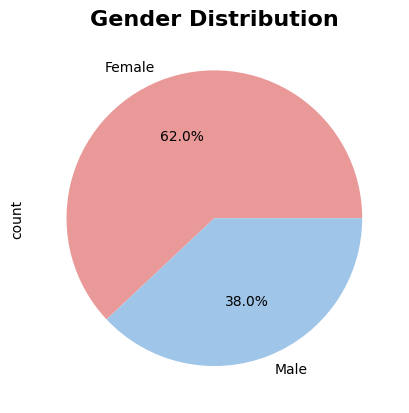

In [276]:
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["#ea9999", "#9fc5e8"])
plt.title("Gender Distribution", fontsize=16, fontweight="bold")
plt.show()

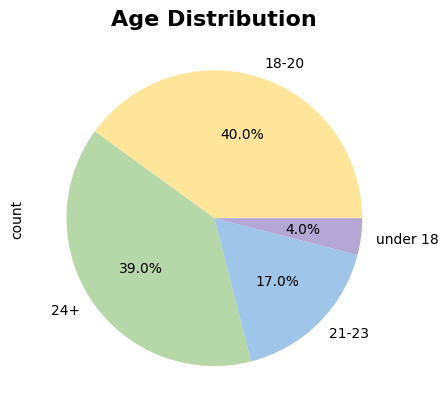

In [277]:
df["Age"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["#ffe599", "#b6d7a8", "#9fc5e8", "#b4a7d6"])
plt.title("Age Distribution", fontsize=16, fontweight="bold")
plt.show()

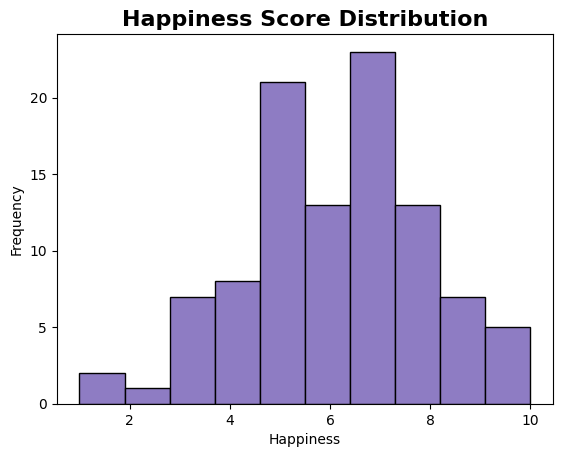

In [278]:
plt.hist(df["Happiness"], bins=10, color=["#8e7cc3"], edgecolor="black")
plt.title("Happiness Score Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Happiness")
plt.ylabel("Frequency")
plt.show()

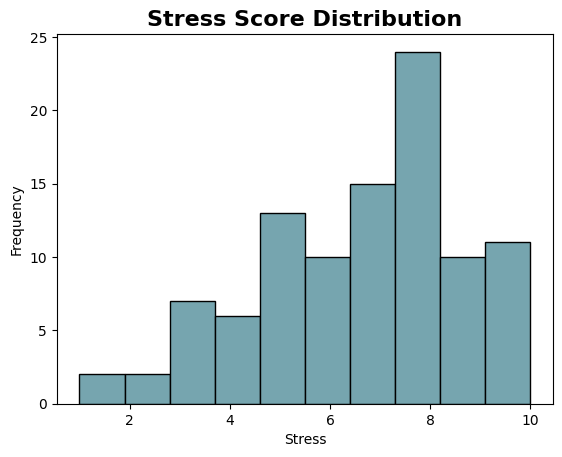

In [279]:
plt.hist(df["Stress"], bins=10, color=["#76a5af"], edgecolor="black")
plt.title("Stress Score Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Stress")
plt.ylabel("Frequency")
plt.show()

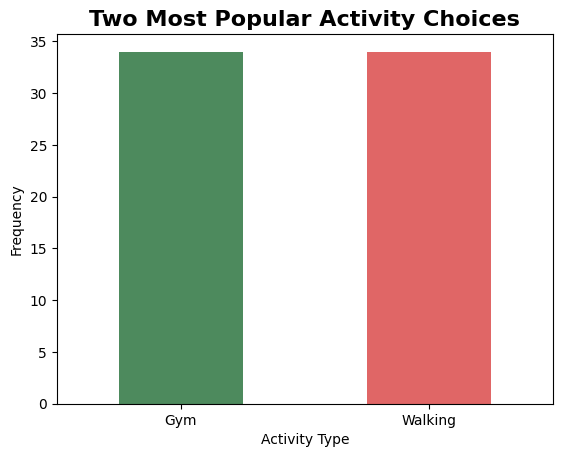

In [280]:
df["Activity_Type"].value_counts().head(2).plot(kind="bar", color=["#4d8a5d", "#e06666"])
plt.title("Two Most Popular Activity Choices", fontsize=16, fontweight="bold")
plt.xlabel("Activity Type")
plt.ylabel("Frequency")
plt.gca().set_xticklabels(["Gym", "Walking"])
plt.xticks(rotation=0)
plt.show()

Text(0, 0.5, 'Stress')

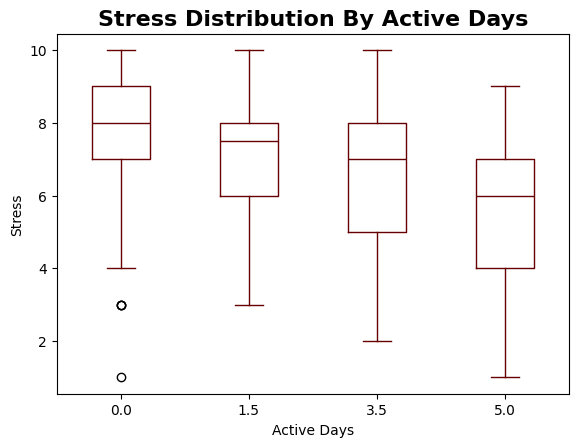

In [281]:
df.boxplot(column="Stress", by="Active_Days", grid=False, color="#660000")
plt.title("Stress Distribution By Active Days", fontsize=16, fontweight="bold")
plt.suptitle("")
plt.xlabel("Active Days")
plt.ylabel("Stress")

Text(0, 0.5, 'Wellbeing')

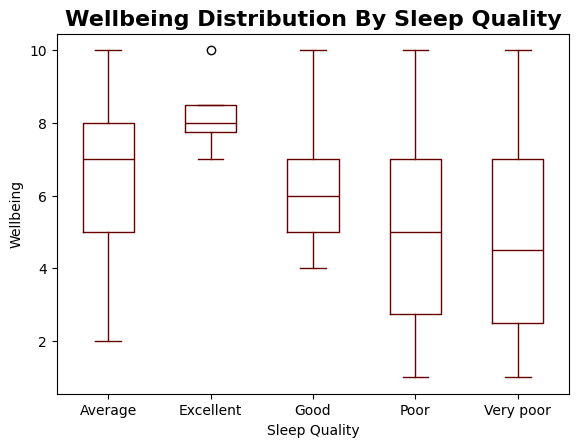

In [282]:
df.boxplot(column="Wellbeing", by="Sleep_Quality", grid=False, color="#660000")
plt.title("Wellbeing Distribution By Sleep Quality", fontsize=16, fontweight="bold")
plt.suptitle("")
plt.xlabel("Sleep Quality")
plt.ylabel("Wellbeing")

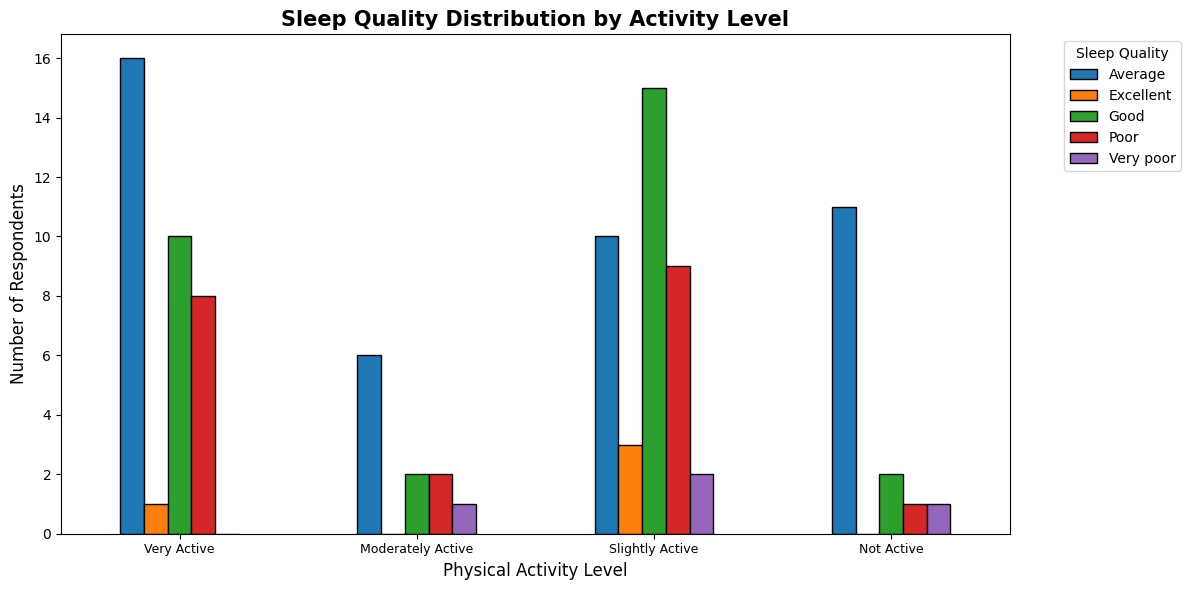

In [283]:
sleep_activity_data = pd.crosstab(df['Activity_Level'], df['Sleep_Quality'])

sleep_activity_data.plot(kind='bar', figsize=(12, 6), edgecolor='black')

plt.title("Sleep Quality Distribution by Activity Level", fontsize=15, fontweight="bold")
plt.xlabel("Physical Activity Level", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.legend(title="Sleep Quality", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().set_xticklabels(["Very Active", "Moderately Active", "Slightly Active", "Not Active"], fontsize=9)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

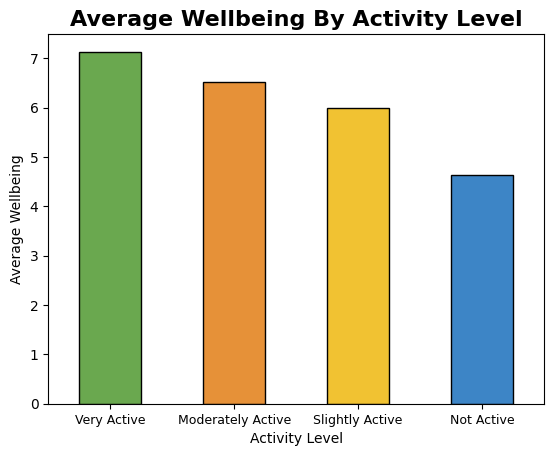

In [284]:
avg_wellbeing = df.groupby("Activity_Level")["Wellbeing"].mean().sort_values(ascending=False)
avg_wellbeing.plot(kind="bar", color=["#6aa84f", "#e69138", "#f1c232", "#3d85c6"], edgecolor="black")
plt.gca().set_xticklabels(["Very Active", "Moderately Active", "Slightly Active", "Not Active"], fontsize=9)
plt.xticks(rotation=0)
plt.title("Average Wellbeing By Activity Level", fontsize=16, fontweight="bold")
plt.xlabel("Activity Level")
plt.ylabel("Average Wellbeing")
plt.show()


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Improves'),
  Text(1, 0, 'Stays The Same'),
  Text(2, 0, 'Not Applicable'),
  Text(3, 0, 'Gets Worse')])

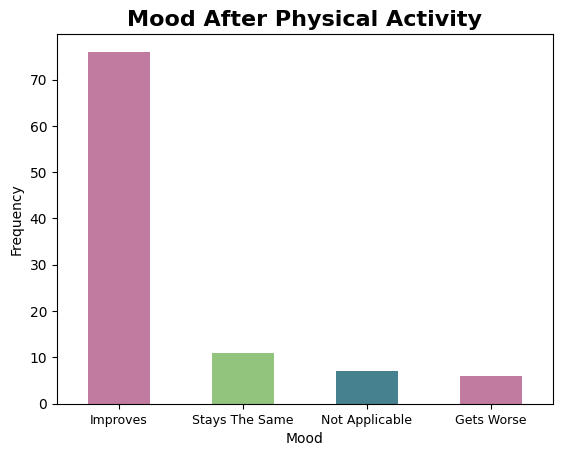

In [285]:
df["Mood_Change"].value_counts().plot(kind="bar", color=["#c27ba0", "#93c47d", "#45818e"])
plt.gca().set_xticklabels(["Improves", "Stays The Same", "Not Applicable", "Gets Worse"], fontsize=9)
plt.title("Mood After Physical Activity", fontsize=16, fontweight="bold")
plt.xlabel("Mood")
plt.ylabel("Frequency")
plt.xticks(rotation=0)

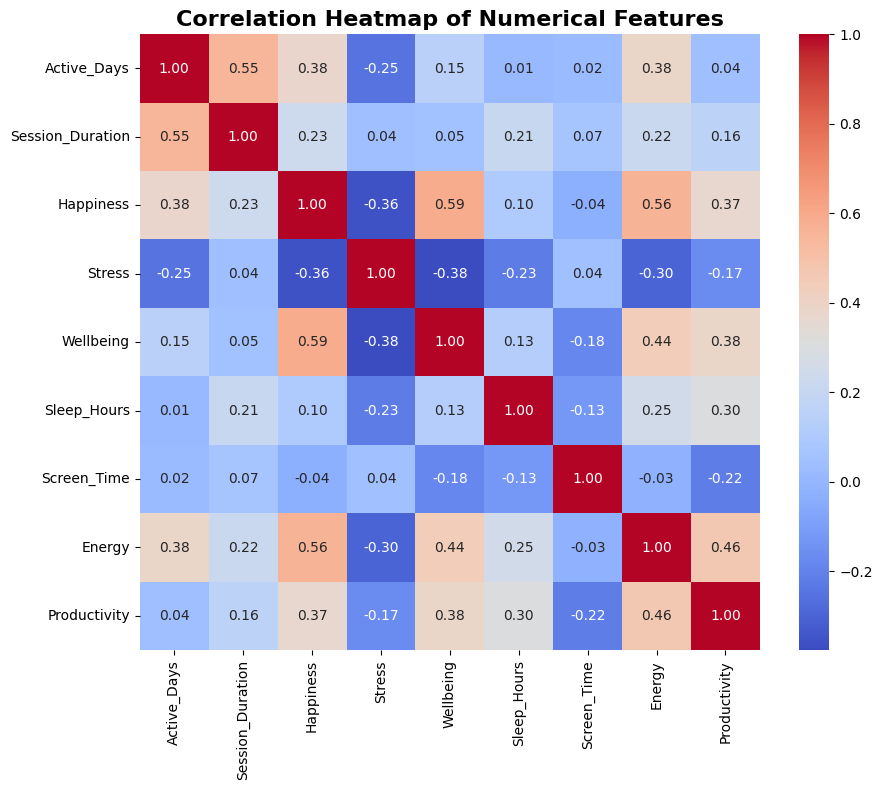

In [286]:
numerical_cols = [
    'Active_Days', 'Session_Duration', 'Happiness', 'Stress', 'Wellbeing',
    'Sleep_Hours', 'Screen_Time', 'Energy', 'Productivity'
]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features", fontsize=16, fontweight="bold")
plt.show()